
--- ĐANG NẠP DỮ LIỆU ---
✓ Nạp dữ liệu thành công!
✓ Đồng bộ tên cột thành công!

--- ĐANG GỘP BẢNG ---
✓ Gộp bảng thành công!

--- ĐANG XỬ LÝ DỮ LIỆU ---
✓ Tính TotalAmount thành công!

Kích thước dữ liệu sau khi gộp:
(4872000, 36)

5 dòng đầu tiên:


,SalesID,SalesPersonID,CustomerID,ProductID,Quantity,Discount,TotalPrice,SalesDate,TransactionNumber,ProductName,...,CountryName,CountryCode,Date,Year,MonthNumber,MonthName,Quarter,YearMonth,Weekday,TotalAmount
0,3182459,19,61257,383,16,0,0,2018-01-24 18:07:34.320,YPVSD0JOA3CS4383LKME,Cake - Box Window 10x10x2.5,...,United States,AR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,159.5104
1,3183056,19,59594,368,16,0,0,2018-03-12 16:16:26.070,PKS07L725ITSDSDDBWMJ,Flour - Teff,...,United States,AR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,292.7648
2,3184098,19,60186,358,16,0,0,2018-05-04 02:28:01.040,9OLIIAZJL80SFHQF7IXN,"Cheese - Boursin, Garlic / Herbs",...,United States,AR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1355.3776
3,3185495,19,61905,157,16,0,0,2018-05-01 14:15:59.860,5U2RZYTAXEY5Q7SECA41,"Juice - Cranberry, 341 Ml",...,United States,AR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225.7312
4,3185869,19,60313,366,16,0,0,2018-04-25 09:10:26.980,Q0J9Y01BNRQ7AER7UTXG,Tahini Paste,...,United States,AR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1287.1728



--- ĐANG TÍNH KPI KHÁCH HÀNG ---
✓ Tính KPI thành công!

--- ĐANG TÍNH RECENCY ---
✓ Tính Recency thành công!

--- ĐANG PHÂN KHÚC KHÁCH HÀNG ---

✓ Phân bố Customer Segment:
CustomerSegmentName
Low Value    47081
VIP          36469
Regular      15209
Name: count, dtype: int64

--- ĐANG VẼ BIỂU ĐỒ BI ---


/tmp/ipykernel_2026/3929940141.py:321: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


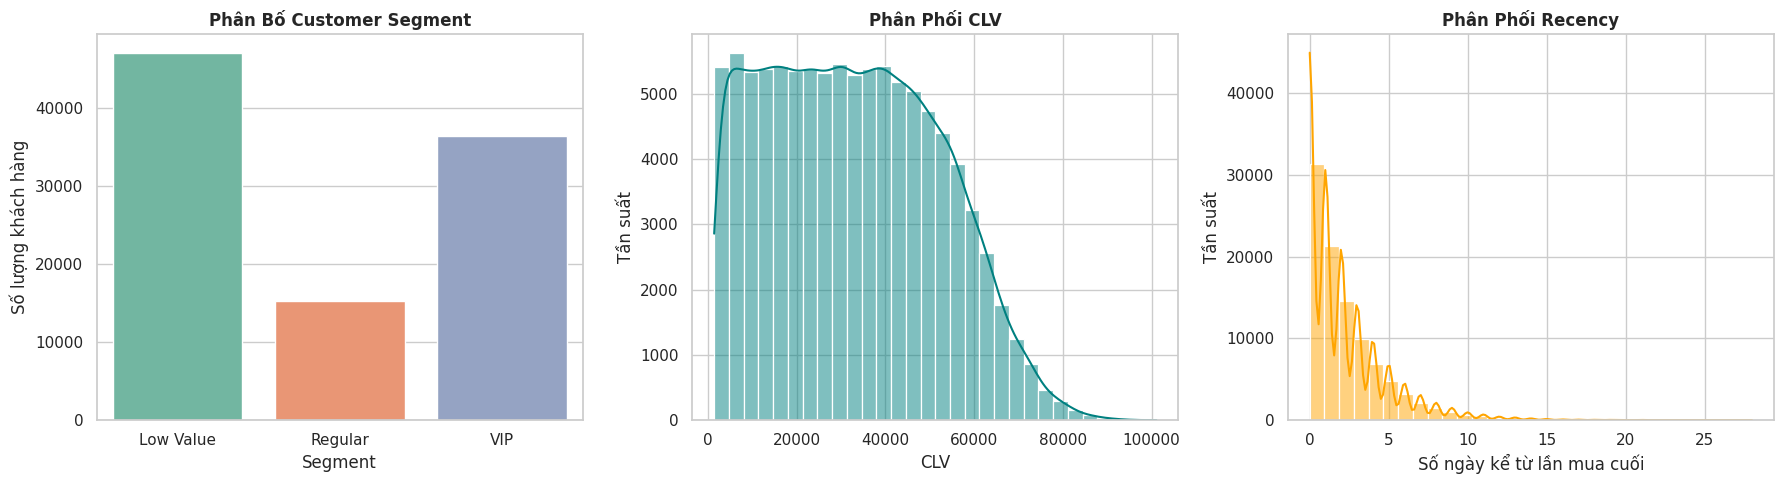


--- THỐNG KÊ SEGMENT ---


,CLV,PurchaseFrequency,Recency,AOV
CustomerSegmentName,,,,
Low Value,20157.17,46.78,1.24,448.19
Regular,30005.33,46.00,6.90,660.07
VIP,49735.95,54.02,1.35,935.00



✓ MỨC 1 HOÀN THÀNH!
✓ Đã lưu file: customer_analytics.csv
✓ Sẵn sàng sử dụng cho MỨC 2 (Machine Learning)

5 dòng đầu tiên:


,CustomerID,CLV,PurchaseFrequency,BasketSize,CountryName,CategoryName,AOV,Recency,CustomerSegment,CustomerSegmentName
0,1,2661.5407,53,1.0,United States,Produce,50.217749,3,0,Low Value
1,2,2617.6093,49,1.0,United States,Confections,53.420598,5,2,Regular
2,3,2386.2992,53,1.0,United States,Produce,45.024513,0,0,Low Value
3,4,2431.9033,52,1.0,United States,Cereals,46.767371,1,0,Low Value
4,5,1894.0595,42,1.0,United States,Meat,45.096655,0,0,Low Value


In [8]:
# ==============================================================================
# MỨC 1 - PHẦN 1
# BUSINESS INTELLIGENCE: NẠP DỮ LIỆU VÀ TIỀN XỬ LÝ
# ==============================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# =========================
# Cấu hình giao diện
# =========================
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# =========================
# Hàm nạp file thông minh
# =========================
def nap_file_thong_minh(ten_file_chuan):
    if not os.path.exists(ten_file_chuan):
        print(f" Vui lòng chọn tải file '{ten_file_chuan}':")

        uploaded = files.upload()

        ten_file_upload = list(uploaded.keys())[0]

        if ten_file_upload != ten_file_chuan:
            os.rename(ten_file_upload, ten_file_chuan)

    # Thử đọc bằng dấu ;
    df = pd.read_csv(
        ten_file_chuan,
        sep=';',
        low_memory=False
    )

    # Nếu chỉ có 1 cột thì thử đọc bằng dấu ,
    if df.shape[1] <= 1:
        df = pd.read_csv(
            ten_file_chuan,
            sep=',',
            low_memory=False
        )

    return df


# ==============================================================================
# 1. NẠP DỮ LIỆU
# ==============================================================================
print("\n--- ĐANG NẠP DỮ LIỆU ---")

sales = nap_file_thong_minh('Fact_Sales.csv')
customers = nap_file_thong_minh('Dim_customers.csv')
products = nap_file_thong_minh('Dim_products.csv')
locations = nap_file_thong_minh('Dim_Location.csv')
salesperson = nap_file_thong_minh('Dim_SalesPerson.csv')
dates = nap_file_thong_minh('Dim_date.csv')

print(" Nạp dữ liệu thành công!")


# ==============================================================================
# 2. ĐỒNG BỘ TÊN CỘT
# ==============================================================================
ban_do_ten_cot = {
    'productid': 'ProductID',
    'customerid': 'CustomerID',
    'cityid': 'CityID',
    'salesdate': 'SalesDate',
    'quantity': 'Quantity',
    'price': 'Price',
    'categoryname': 'CategoryName',
    'countryname': 'CountryName',
    'salesid': 'SalesID',
    'date': 'Date'
}

for df in [
    sales,
    customers,
    products,
    locations,
    salesperson,
    dates
]:
    df.columns = df.columns.str.strip()

    mapping_thuong = {
        k.lower(): v
        for k, v in ban_do_ten_cot.items()
    }

    df.columns = [
        mapping_thuong.get(col.lower(), col)
        for col in df.columns
    ]

print(" Đồng bộ tên cột thành công!")


# ==============================================================================
# 3. GỘP CÁC BẢNG
# ==============================================================================
print("\n--- ĐANG GỘP BẢNG ---")

sales_full = pd.merge(
    sales,
    products,
    on='ProductID',
    how='left'
)

sales_full = pd.merge(
    sales_full,
    customers,
    on='CustomerID',
    how='left'
)

sales_full = pd.merge(
    sales_full,
    locations,
    on='CityID',
    how='left'
)

sales_full = pd.merge(
    sales_full,
    dates,
    left_on='SalesDate',
    right_on='Date',
    how='left'
)

print(" Gộp bảng thành công!")


# ==============================================================================
# 4. XỬ LÝ DỮ LIỆU
# ==============================================================================
print("\n--- ĐANG XỬ LÝ DỮ LIỆU ---")

# Chuyển đổi Quantity và Price về dạng số
for col in ['Quantity', 'Price']:

    if sales_full[col].dtype == 'object':

        sales_full[col] = (
            sales_full[col]
            .astype(str)
            .str.replace(',', '.', regex=False)
        )

sales_full['Quantity'] = pd.to_numeric(
    sales_full['Quantity'],
    errors='coerce'
).fillna(0)

sales_full['Price'] = pd.to_numeric(
    sales_full['Price'],
    errors='coerce'
).fillna(0)


# ==============================================================================
# 5. TÍNH TOTAL AMOUNT
# ==============================================================================
sales_full['TotalAmount'] = (
    sales_full['Quantity']
    * sales_full['Price']
)

print(" Tính TotalAmount thành công!")

print("\nKích thước dữ liệu sau khi gộp:")
print(sales_full.shape)

print("\n5 dòng đầu tiên:")
display(sales_full.head())
# ==============================================================================
# MỨC 1 - PHẦN 2
# KPI CRM + RFM + CUSTOMER SEGMENTATION + BI DASHBOARD
# ==============================================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ==============================================================================
# 6. TÍNH KPI CRM
# ==============================================================================
print("\n--- ĐANG TÍNH KPI KHÁCH HÀNG ---")

customer_df = sales_full.groupby('CustomerID').agg({
    'TotalAmount': 'sum',
    'SalesID': 'count',
    'Quantity': 'mean',
    'CountryName': lambda x:
        x.fillna('Unknown').iloc[0]
        if len(x) > 0 else 'Unknown',
    'CategoryName': lambda x:
        x.fillna('Unknown').iloc[0]
        if len(x) > 0 else 'Unknown'
}).reset_index()

customer_df.columns = [
    'CustomerID',
    'CLV',
    'PurchaseFrequency',
    'BasketSize',
    'CountryName',
    'CategoryName'
]

# Average Order Value
customer_df['AOV'] = (
    customer_df['CLV']
    / customer_df['PurchaseFrequency']
)

customer_df['AOV'] = customer_df['AOV'].fillna(0)

print(" Tính KPI thành công!")

# ==============================================================================
# 7. TÍNH RECENCY (RFM)
# ==============================================================================
print("\n--- ĐANG TÍNH RECENCY ---")

sales_full['SalesDate'] = pd.to_datetime(
    sales_full['SalesDate'],
    errors='coerce'
)

snapshot_date = sales_full['SalesDate'].max()

last_purchase = (
    sales_full.groupby('CustomerID')['SalesDate']
    .max()
)

recency = (
    snapshot_date - last_purchase
).dt.days

customer_df['Recency'] = (
    customer_df['CustomerID']
    .map(recency)
)

customer_df['Recency'] = (
    customer_df['Recency']
    .fillna(customer_df['Recency'].median())
)

print("✓ Tính Recency thành công!")

# ==============================================================================
# 8. CUSTOMER SEGMENTATION BẰNG RFM + K-MEANS
# ==============================================================================
print("\n--- ĐANG PHÂN KHÚC KHÁCH HÀNG ---")

rfm = customer_df[
    ['Recency', 'PurchaseFrequency', 'CLV']
].copy()

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_df['CustomerSegment'] = (
    kmeans.fit_predict(rfm_scaled)
)

# Đặt tên Segment dựa trên CLV trung bình
segment_summary = (
    customer_df.groupby('CustomerSegment')['CLV']
    .mean()
    .sort_values()
)

mapping = {
    segment_summary.index[0]: 'Low Value',
    segment_summary.index[1]: 'Regular',
    segment_summary.index[2]: 'VIP'
}

customer_df['CustomerSegmentName'] = (
    customer_df['CustomerSegment']
    .map(mapping)
)

print("\nPhân bố Customer Segment:")
print(
    customer_df['CustomerSegmentName']
    .value_counts()
)

# ==============================================================================
# 9. BI DASHBOARD
# ==============================================================================
print("\n--- ĐANG VẼ BIỂU ĐỒ BI ---")

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

# Biểu đồ Segment
sns.countplot(
    data=customer_df,
    x='CustomerSegmentName',
    palette='Set2',
    ax=axes[0]
)

axes[0].set_title(
    'Phân Bố Customer Segment',
    fontweight='bold'
)

axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Số lượng khách hàng')

# Phân phối CLV
sns.histplot(
    customer_df[
        customer_df['CLV'] > 0
    ]['CLV'],
    bins=30,
    kde=True,
    color='teal',
    ax=axes[1]
)

axes[1].set_title(
    'Phân Phối CLV',
    fontweight='bold'
)

axes[1].set_xlabel('CLV')
axes[1].set_ylabel('Tần suất')

# Phân phối Recency
sns.histplot(
    customer_df['Recency'],
    bins=30,
    kde=True,
    color='orange',
    ax=axes[2]
)

axes[2].set_title(
    'Phân Phối Recency',
    fontweight='bold'
)

axes[2].set_xlabel('Số ngày kể từ lần mua cuối')
axes[2].set_ylabel('Tần suất')

plt.tight_layout()
plt.show()

# ==============================================================================
# 10. THỐNG KÊ SEGMENT
# ==============================================================================
print("\n--- THỐNG KÊ SEGMENT ---")

segment_stats = customer_df.groupby(
    'CustomerSegmentName'
)[
    ['CLV',
     'PurchaseFrequency',
     'Recency',
     'AOV']
].mean().round(2)

display(segment_stats)

# ==============================================================================
# 11. XUẤT FILE CHO MỨC 2
# ==============================================================================
customer_df.to_csv(
    'customer_analytics.csv',
    index=False
)

print("\n✓ MỨC 1 HOÀN THÀNH!")

print("✓ Đã lưu file: customer_analytics.csv")
print("✓ Sẵn sàng sử dụng cho MỨC 2 (Machine Learning)")

print("\n5 dòng đầu tiên:")
display(customer_df.head())



--- MỨC 2: NẠP FILE CUSTOMER ANALYTICS ---
 Đọc dữ liệu thành công!
Kích thước dữ liệu: (98759, 10)


,CustomerID,CLV,PurchaseFrequency,BasketSize,CountryName,CategoryName,AOV,Recency,CustomerSegment,CustomerSegmentName
0,1,2661.5407,53,1.0,United States,Produce,50.217749,3,0,Low Value
1,2,2617.6093,49,1.0,United States,Confections,53.420598,5,2,Regular
2,3,2386.2992,53,1.0,United States,Produce,45.024513,0,0,Low Value
3,4,2431.9033,52,1.0,United States,Cereals,46.767371,1,0,Low Value
4,5,1894.0595,42,1.0,United States,Meat,45.096655,0,0,Low Value



--- CHUẨN BỊ DỮ LIỆU ---
Số đặc trưng sau Encoding: 15
Train: (79007, 15)
Test : (19752, 15)

MÔ HÌNH: Logistic Regression

Accuracy : 0.997
Precision: 0.997
Recall   : 0.997
F1-score : 0.997

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9416
           1       1.00      1.00      1.00      7294
           2       1.00      1.00      1.00      3042

    accuracy                           1.00     19752
   macro avg       1.00      1.00      1.00     19752
weighted avg       1.00      1.00      1.00     19752



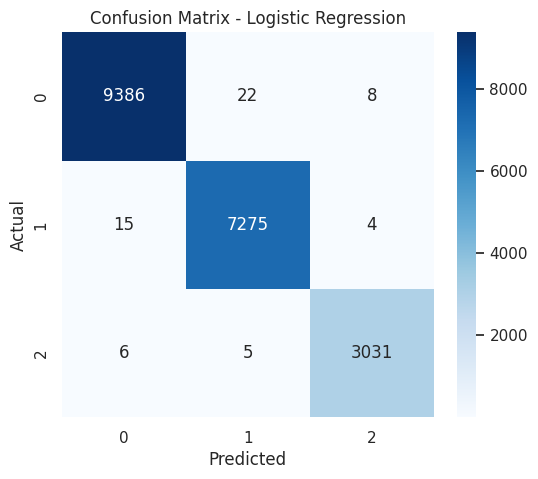


MÔ HÌNH: Decision Tree

Accuracy : 0.9535
Precision: 0.9539
Recall   : 0.9535
F1-score : 0.9534

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      9416
           1       0.94      0.96      0.95      7294
           2       0.98      0.89      0.93      3042

    accuracy                           0.95     19752
   macro avg       0.96      0.94      0.95     19752
weighted avg       0.95      0.95      0.95     19752



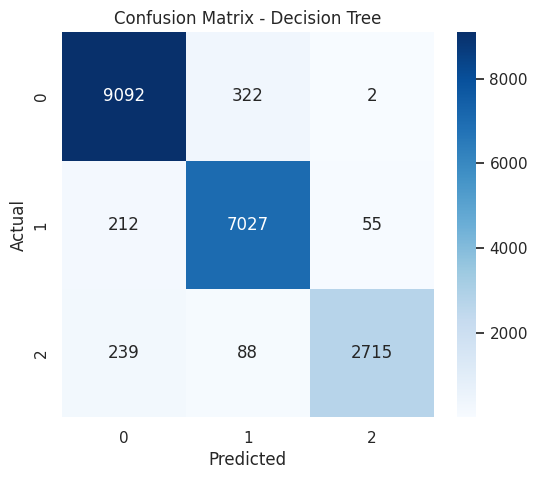


MÔ HÌNH: Random Forest

Accuracy : 0.9354
Precision: 0.9366
Recall   : 0.9354
F1-score : 0.9353

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      9416
           1       0.94      0.92      0.93      7294
           2       0.98      0.88      0.93      3042

    accuracy                           0.94     19752
   macro avg       0.95      0.92      0.93     19752
weighted avg       0.94      0.94      0.94     19752



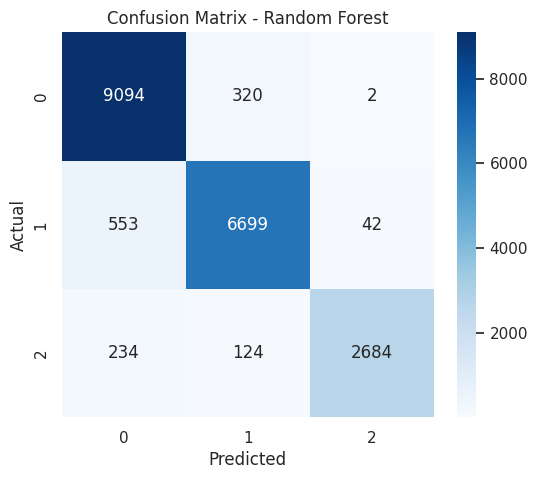


MÔ HÌNH: XGBoost

Accuracy : 0.9981
Precision: 0.9981
Recall   : 0.9981
F1-score : 0.9981

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9416
           1       1.00      1.00      1.00      7294
           2       1.00      1.00      1.00      3042

    accuracy                           1.00     19752
   macro avg       1.00      1.00      1.00     19752
weighted avg       1.00      1.00      1.00     19752



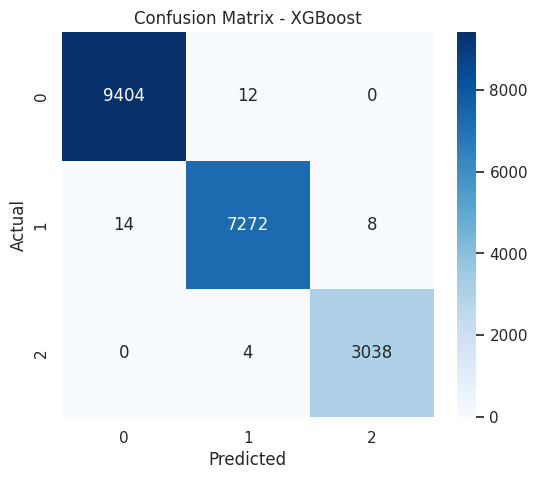


--- BẢNG SO SÁNH HIỆU NĂNG ---


,Model,Accuracy,Precision,Recall,F1-score
3,XGBoost,0.9981,0.9981,0.9981,0.9981
0,Logistic Regression,0.9970,0.9970,0.9970,0.9970
1,Decision Tree,0.9535,0.9539,0.9535,0.9534
2,Random Forest,0.9354,0.9366,0.9354,0.9353


/tmp/ipykernel_2026/2937050409.py:256: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


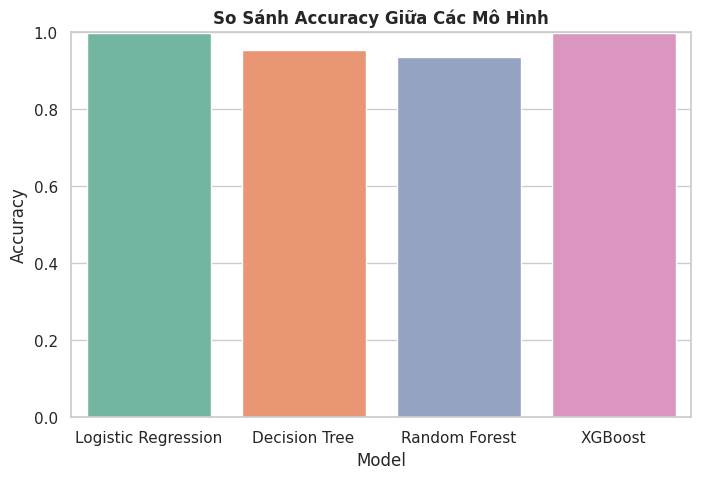


✓ MỨC 2 HOÀN THÀNH!

--- MỨC 3: EXPLAINABLE AI (SHAP) ---
 Mô hình được giải thích: Random Forest
 Số mẫu dùng để giải thích: 300

--- ĐANG TÍNH SHAP VALUES ---
 Tính SHAP thành công!

--- BIỂU ĐỒ TẦM QUAN TRỌNG CỦA ĐẶC TRƯNG ---


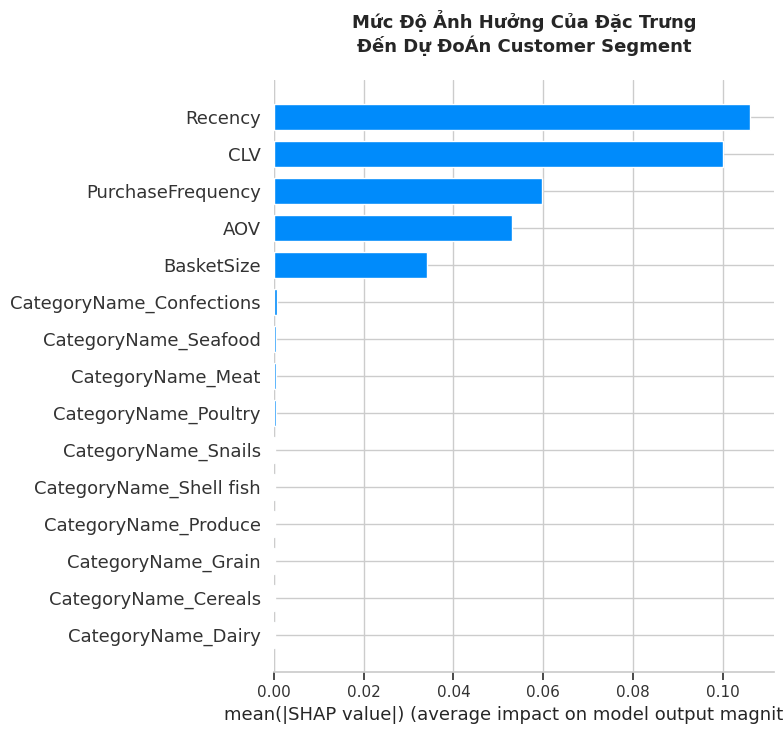


--- BIỂU ĐỒ CHI TIẾT SHAP ---


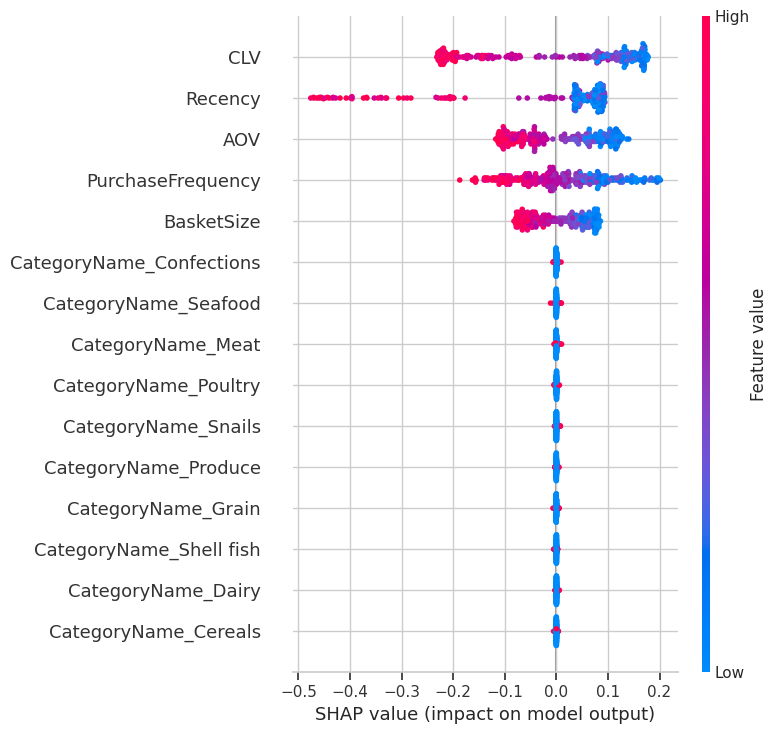


--- TOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT ---


,Feature,Importance
4,Recency,0.106115
0,CLV,0.100078
1,PurchaseFrequency,0.059685
3,AOV,0.053018
2,BasketSize,0.034161
6,CategoryName_Confections,0.000703
12,CategoryName_Seafood,0.000597
9,CategoryName_Meat,0.000556
10,CategoryName_Poultry,0.000435
14,CategoryName_Snails,0.000341


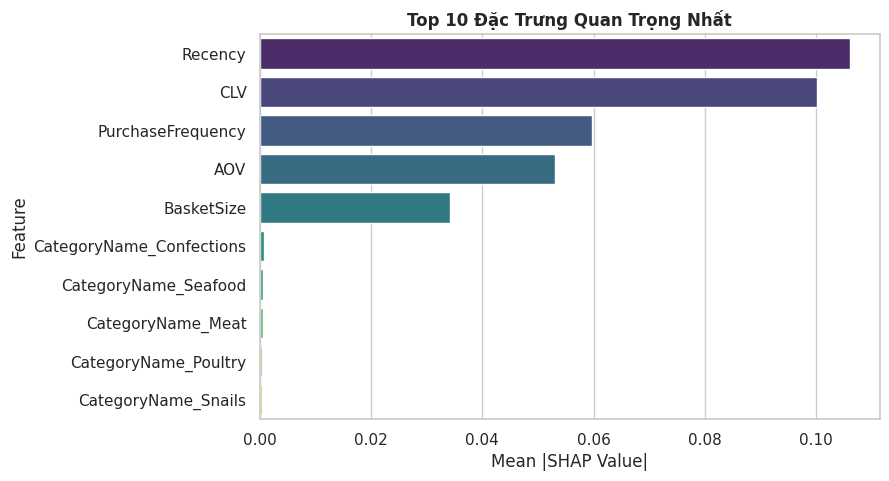


 MỨC 3 HOÀN THÀNH!

KẾT LUẬN:
- SHAP giúp giải thích vì sao AI dự đoán khách hàng thuộc VIP, Regular hoặc Low Value.
- Những đặc trưng có SHAP Value lớn hơn sẽ ảnh hưởng mạnh hơn đến quyết định của mô hình.
- Doanh nghiệp có thể dựa vào các đặc trưng quan trọng để xây dựng chiến lược CRM và Marketing phù hợp.


In [9]:
# ==============================================================================
# MỨC 2 - MACHINE LEARNING:
# DỰ ĐOÁN CUSTOMER SEGMENT
# ==============================================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print("\n--- MỨC 2: NẠP FILE CUSTOMER ANALYTICS ---")

ten_file = 'customer_analytics.csv'

# Nếu chưa có file trên Colab thì yêu cầu tải lên
if not os.path.exists(ten_file):
    print(f" Vui lòng tải file '{ten_file}' lên:")

    uploaded = files.upload()

    ten_upload = list(uploaded.keys())[0]

    if ten_upload != ten_file:
        os.rename(ten_upload, ten_file)

# Đọc dữ liệu
df_ml = pd.read_csv(ten_file)

print(" Đọc dữ liệu thành công!")
print("Kích thước dữ liệu:", df_ml.shape)

display(df_ml.head())


# ==============================================================================
# CHUẨN BỊ DỮ LIỆU
# ==============================================================================
print("\n--- CHUẨN BỊ DỮ LIỆU ---")

X = df_ml[
    [
        'CLV',
        'PurchaseFrequency',
        'BasketSize',
        'AOV',
        'Recency',
        'CountryName',
        'CategoryName'
    ]
]

y = df_ml['CustomerSegment']

# One-Hot Encoding
X = pd.get_dummies(
    X,
    columns=[
        'CountryName',
        'CategoryName'
    ],
    drop_first=True
)

print("Số đặc trưng sau Encoding:", X.shape[1])


# ==============================================================================
# CHIA TẬP TRAIN / TEST
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


# ==============================================================================
# CHUẨN HÓA DỮ LIỆU
# ==============================================================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ==============================================================================
# KHAI BÁO CÁC MÔ HÌNH
# ==============================================================================
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=4,
        random_state=42,
        eval_metric='mlogloss'
    )
}


# ==============================================================================
# HUẤN LUYỆN VÀ ĐÁNH GIÁ
# ==============================================================================
performance = []

for name, model in models.items():

    print("\n" + "=" * 60)
    print("MÔ HÌNH:", name)
    print("=" * 60)

    # Logistic cần dữ liệu chuẩn hóa
    if name == "Logistic Regression":
        X_tr = X_train_scaled
        X_te = X_test_scaled
    else:
        X_tr = X_train
        X_te = X_test

    # Train
    model.fit(X_tr, y_train)

    # Predict
    y_pred = model.predict(X_te)

    # Metrics
    acc = accuracy_score(y_test, y_pred)

    prec = precision_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    rec = recall_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )

    performance.append(
        [name, acc, prec, rec, f1]
    )

    print("\nAccuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(
        f'Confusion Matrix - {name}'
    )

    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()


# ==============================================================================
# BẢNG SO SÁNH MÔ HÌNH
# ==============================================================================
df_result = pd.DataFrame(
    performance,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1-score'
    ]
)

print("\n--- BẢNG SO SÁNH HIỆU NĂNG ---")

display(
    df_result.sort_values(
        by='Accuracy',
        ascending=False
    ).round(4)
)

# Vẽ biểu đồ Accuracy
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_result,
    x='Model',
    y='Accuracy',
    palette='Set2'
)

plt.title(
    'So Sánh Accuracy Giữa Các Mô Hình',
    fontweight='bold'
)

plt.ylim(
    0,
    1
)

plt.show()

print("\n✓ MỨC 2 HOÀN THÀNH!")
# ==============================================================================
# MỨC 3 - EXPLAINABLE AI (SHAP)
# GIẢI THÍCH QUYẾT ĐỊNH CỦA AI TRONG DỰ ĐOÁN CUSTOMER SEGMENT
# ==============================================================================

import shap
import warnings

warnings.filterwarnings('ignore')

print("\n--- MỨC 3: EXPLAINABLE AI (SHAP) ---")

# ==============================================================================
# 1. CHỌN MÔ HÌNH CẦN GIẢI THÍCH
# ==============================================================================

# Sử dụng Random Forest đã huấn luyện ở Mức 2
model_target = models["Random Forest"]

print(" Mô hình được giải thích:", "Random Forest")


# ==============================================================================
# 2. LẤY MẪU DỮ LIỆU ĐỂ GIẢI THÍCH
# ==============================================================================

sample_size = min(300, X_train.shape[0])

X_sample = X_train.sample(
    n=sample_size,
    random_state=42
)

print(" Số mẫu dùng để giải thích:", sample_size)


# ==============================================================================
# 3. TÍNH SHAP VALUES
# ==============================================================================

print("\n--- ĐANG TÍNH SHAP VALUES ---")

explainer = shap.TreeExplainer(model_target)

shap_values = explainer.shap_values(X_sample)

print(" Tính SHAP thành công!")


# ==============================================================================
# 4. XỬ LÝ SHAP VALUES CHO BÀI TOÁN MULTI-CLASS
# ==============================================================================

if isinstance(shap_values, list):

    # Trường hợp SHAP trả về list
    shap_processed = np.mean(
        np.abs(np.array(shap_values)),
        axis=0
    )

elif len(shap_values.shape) == 3:

    # Trường hợp Multi-class
    shap_processed = np.mean(
        np.abs(shap_values),
        axis=2
    )

else:

    shap_processed = shap_values


# ==============================================================================
# 5. BIỂU ĐỒ SHAP BAR
# ==============================================================================

print("\n--- BIỂU ĐỒ TẦM QUAN TRỌNG CỦA ĐẶC TRƯNG ---")

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_processed,
    X_sample,
    plot_type="bar",
    show=False
)

plt.title(
    "Mức Độ Ảnh Hưởng Của Đặc Trưng\n"
    "Đến Dự ĐoÁn Customer Segment",
    fontsize=13,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()


# ==============================================================================
# 6. BIỂU ĐỒ SHAP BEESWARM
# ==============================================================================

print("\n--- BIỂU ĐỒ CHI TIẾT SHAP ---")

try:

    if isinstance(shap_values, list):

        shap.summary_plot(
            shap_values[0],
            X_sample
        )

    elif len(shap_values.shape) == 3:

        shap.summary_plot(
            shap_values[:, :, 0],
            X_sample
        )

    else:

        shap.summary_plot(
            shap_values,
            X_sample
        )

except:

    print("Không thể hiển thị Beeswarm Plot.")


# ==============================================================================
# 7. TOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT
# ==============================================================================

importance = np.mean(
    np.abs(shap_processed),
    axis=0
)

importance_df = pd.DataFrame({
    'Feature': X_sample.columns,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\n--- TOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT ---")

display(
    importance_df.head(10)
)


# ==============================================================================
# 8. BIỂU ĐỒ TOP 10 FEATURE
# ==============================================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=importance_df.head(10),
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title(
    'Top 10 Đặc Trưng Quan Trọng Nhất',
    fontweight='bold'
)

plt.xlabel('Mean |SHAP Value|')
plt.ylabel('Feature')

plt.show()


# ==============================================================================
# 9. KẾT LUẬN
# ==============================================================================

print("\n MỨC 3 HOÀN THÀNH!")

print("\nKẾT LUẬN:")

print(
    "- SHAP giúp giải thích vì sao AI dự đoán khách hàng "
    "thuộc VIP, Regular hoặc Low Value."
)

print(
    "- Những đặc trưng có SHAP Value lớn hơn sẽ ảnh hưởng "
    "mạnh hơn đến quyết định của mô hình."
)

print(
    "- Doanh nghiệp có thể dựa vào các đặc trưng quan trọng "
    "để xây dựng chiến lược CRM và Marketing phù hợp."
)

